<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook1_AIXI_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 — Foundations of an AIXI-Inspired Agent

This notebook introduces the building blocks behind Marcus Hutter's AIXI using executable Python.

**Topics**
1. Agent/environment interaction
2. Grid world
3. Rewards
4. Hypotheses
5. Occam prior
6. Approximate Kolmogorov complexity
7. Bayesian updates
8. Finite-horizon planning
9. Experiments

> This is an educational approximation. Exact AIXI is mathematically uncomputable.


In [1]:
import random, math
import numpy as np
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)


## Environment

In [2]:
class GridWorld:
    ACTIONS=["UP","DOWN","LEFT","RIGHT"]

    def __init__(self,size=8):
        self.size=size
        self.goal=(7,7)
        self.traps={(2,2),(4,5),(5,2)}
        self.reset()

    def reset(self):
        self.pos=(0,0)
        return self.pos

    def step(self,a):
        x,y=self.pos
        if a==0:x=max(0,x-1)
        elif a==1:x=min(self.size-1,x+1)
        elif a==2:y=max(0,y-1)
        elif a==3:y=min(self.size-1,y+1)
        self.pos=(x,y)
        r=-1
        done=False
        if self.pos in self.traps:
            r=-30
        if self.pos==self.goal:
            r=100
            done=True
        return self.pos,r,done

    def render(self):
        g=np.full((self.size,self.size),".",dtype=object)
        for t in self.traps:g[t]="X"
        g[self.goal]="G"
        g[self.pos]="A"
        print("\n".join(" ".join(r) for r in g))


## Hypotheses

In [3]:
class Hypothesis:
    def __init__(self,name,goal_bonus,trap_penalty,complexity):
        self.name=name
        self.goal_bonus=goal_bonus
        self.trap_penalty=trap_penalty
        self.complexity=complexity

hypotheses=[
Hypothesis("Simple",1.0,1.0,1),
Hypothesis("Explorer",1.3,0.8,2),
Hypothesis("Careful",0.9,2.5,2),
Hypothesis("Optimistic",1.8,0.5,3),
Hypothesis("Pessimistic",0.5,3.5,3)
]


## Occam Prior

In [4]:
def occam_prior(hs):
    p=np.array([2**(-h.complexity) for h in hs],float)
    return p/p.sum()

prior=occam_prior(hypotheses)
for h,p in zip(hypotheses,prior):
    print(h.name,p)


Simple 0.4
Explorer 0.2
Careful 0.2
Optimistic 0.1
Pessimistic 0.1


## Bayesian Belief State

In [5]:
class BeliefState:
    def __init__(self,hs):
        self.hs=hs
        self.posterior=occam_prior(hs)

    def update(self,reward):
        like=[]
        for h in self.hs:
            pred=100*h.goal_bonus if reward>0 else -1
            sigma=20*h.complexity
            like.append(math.exp(-((reward-pred)**2)/(2*sigma*sigma)))
        like=np.array(like)
        self.posterior*=like+1e-12
        self.posterior/=self.posterior.sum()

    def plot(self):
        plt.bar([h.name for h in self.hs],self.posterior)
        plt.xticks(rotation=20)
        plt.title("Posterior Beliefs")
        plt.show()


## Planner

In [6]:
class Planner:
    def __init__(self,belief):
        self.belief=belief

    def score(self,state,a,env):
        x,y=state
        if a==0:x=max(0,x-1)
        elif a==1:x=min(env.size-1,x+1)
        elif a==2:y=max(0,y-1)
        elif a==3:y=min(env.size-1,y+1)
        total=0
        for p,h in zip(self.belief.posterior,self.belief.hs):
            r=-1
            if (x,y)==env.goal:r=100*h.goal_bonus
            elif (x,y) in env.traps:r=-30*h.trap_penalty
            total+=p*r
        return total

    def choose(self,state,env):
        vals=[self.score(state,a,env) for a in range(4)]
        return int(np.argmax(vals)),vals


## Agent

In [7]:
class ToyAIXIAgent:
    def __init__(self,hs):
        self.belief=BeliefState(hs)
        self.planner=Planner(self.belief)

    def act(self,state,env):
        return self.planner.choose(state,env)


## Simulation

In [8]:
env=GridWorld()
agent=ToyAIXIAgent(hypotheses)

state=env.reset()
rewards=[]
belief_history=[]

for step in range(50):
    action,vals=agent.act(state,env)
    state,r,done=env.step(action)
    agent.belief.update(r)
    rewards.append(r)
    belief_history.append(agent.belief.posterior.copy())
    print(f"{step:02d} {GridWorld.ACTIONS[action]:>5} state={state} reward={r}")
    if done:
        print("Goal reached")
        break


00    UP state=(0, 0) reward=-1
01    UP state=(0, 0) reward=-1
02    UP state=(0, 0) reward=-1
03    UP state=(0, 0) reward=-1
04    UP state=(0, 0) reward=-1
05    UP state=(0, 0) reward=-1
06    UP state=(0, 0) reward=-1
07    UP state=(0, 0) reward=-1
08    UP state=(0, 0) reward=-1
09    UP state=(0, 0) reward=-1
10    UP state=(0, 0) reward=-1
11    UP state=(0, 0) reward=-1
12    UP state=(0, 0) reward=-1
13    UP state=(0, 0) reward=-1
14    UP state=(0, 0) reward=-1
15    UP state=(0, 0) reward=-1
16    UP state=(0, 0) reward=-1
17    UP state=(0, 0) reward=-1
18    UP state=(0, 0) reward=-1
19    UP state=(0, 0) reward=-1
20    UP state=(0, 0) reward=-1
21    UP state=(0, 0) reward=-1
22    UP state=(0, 0) reward=-1
23    UP state=(0, 0) reward=-1
24    UP state=(0, 0) reward=-1
25    UP state=(0, 0) reward=-1
26    UP state=(0, 0) reward=-1
27    UP state=(0, 0) reward=-1
28    UP state=(0, 0) reward=-1
29    UP state=(0, 0) reward=-1
30    UP state=(0, 0) reward=-1
31    UP

## Reward Curve

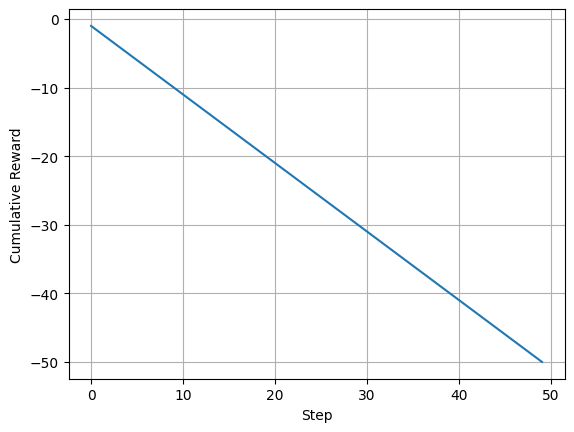

In [9]:
plt.plot(np.cumsum(rewards))
plt.grid()
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.show()


## Belief Evolution

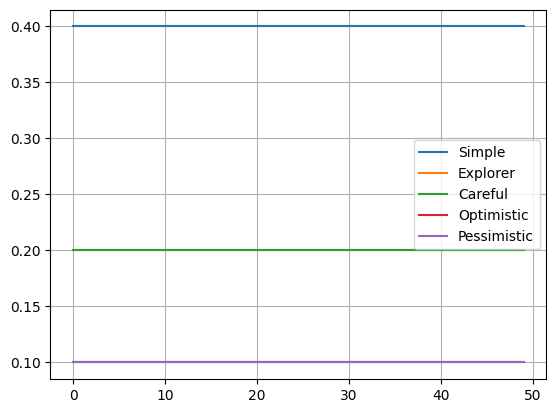

In [10]:
belief_history=np.array(belief_history)
for i,h in enumerate(hypotheses):
    plt.plot(belief_history[:,i],label=h.name)
plt.legend()
plt.grid()
plt.show()


# Exercises

- Increase planning depth.
- Add partial observability.
- Replace handcrafted hypotheses with learned ones.
- Replace fixed complexity with Minimum Description Length.
- Add Monte Carlo rollouts.

Notebook 2 will introduce approximate Solomonoff induction and universal mixtures.
